# Modèles à arbres — leboncoin-private

Le linéaire plafonne (carnet 03 : MAE 2 301 €, R² 0,789) et sort **425 prix négatifs** sur
3 977 prédictions. Deux leviers ici :

1. **Modèles non linéaires** — `RandomForest` (bagging) et `HistGradientBoosting` (boosting).
   La dépréciation d'une voiture n'est pas linéaire : elle s'effondre les trois premières années
   puis s'aplatit. Un arbre capte ça, une droite non.
2. **Catégoriel natif** — `HistGradientBoosting` traite les catégories sans one-hot (jusqu'à 255
   modalités). `marque` (80), `region` (26), `couleur` (17), `etat` (8) passent directement, au
   lieu des 896 colonnes du carnet 03.

**Même split que le carnet 03** (`test_size=0.2`, `random_state=42`) : les chiffres sont
directement comparables.

> Rappel BC04 : les arbres sont plus performants mais **moins interprétables**. Le linéaire reste
> la référence explicable — on ne remplace pas l'un par l'autre, on documente l'arbitrage.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split

CLEAN = Path("../../data/leboncoin-private/processed/annonces_clean.parquet")
df = pd.read_parquet(CLEAN)

MAE_LINEAIRE = 2301  # carnet 03, meme split
R2_LINEAIRE = 0.789
print(f"{len(df)} annonces | reference lineaire : MAE {MAE_LINEAIRE:,} EUR, R2 {R2_LINEAIRE}")

19882 annonces | reference lineaire : MAE 2,301 EUR, R2 0.789


## 1. Jeu de variables

Deux différences avec le carnet 03, dictées par la nature des arbres :

- **`etat` en catégoriel natif** plutôt qu'en ordinal. Le carnet 03 a montré que l'échelle du
  sens commun n'est pas régulièrement espacée en prix — un arbre n'a de toute façon pas besoin
  qu'elle le soit, il coupe où il veut.
- **`marque` conservée.** Le problème d'emboîtement marque/modèle du carnet 03 était un problème
  de **colinéarité**, propre aux modèles linéaires. Un arbre s'en moque : il utilisera l'une ou
  l'autre selon ce qui découpe le mieux.

`modele` (804 modalités) dépasse la limite des 255 du catégoriel natif → traité à part en
section 5.

In [2]:
NUM = ["age", "kilometrage", "puissance_din", "puissance_fisc", "portes", "places",
       "critair", "ct_valide_jusqu_a", "boite_auto", "niveau"]
CAT = ["energie_grp", "marque", "couleur", "region", "etat"]

X = df[NUM + CAT].copy()
X[NUM] = X[NUM].astype("float64")
for c in CAT:
    X[c] = X[c].fillna("(inconnu)").astype("category")
y = df["prix_eur"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print("train:", len(X_train), "| test:", len(X_test))
print()
print("modalites par variable categorielle :")
for c in CAT:
    print(f"  {c:<14}{X[c].nunique():>4}")

train: 15905 | test: 3977

modalites par variable categorielle :
  energie_grp      6
  marque          80
  couleur         18
  region          26
  etat             8


## 2. Panel de modèles

Trois modèles, chacun aussi en variante **log-cible**. `TransformedTargetRegressor` applique
`log1p` avant l'entraînement et `expm1` sur les prédictions : **les scores restent en euros**,
donc comparables.

Le carnet 03 a montré que la cible log fait exploser le linéaire (R² −2,59) tout en améliorant
nettement le bas de la distribution. On vérifie si les arbres, moins sensibles aux résidus
extrêmes, en tirent le bénéfice sans le coût.

**Le classement se lit sur le R² de validation croisée**, pas sur le test : choisir le meilleur
d'après le test serait une fuite de sélection. Le test ne sert qu'à confirmer.

In [3]:
def en_log(estimateur):
    return TransformedTargetRegressor(regressor=estimateur, func=np.log1p, inverse_func=np.expm1)


def hgb():
    # categorical_features par nom : sklearn encode les categories nativement, sans one-hot.
    return HistGradientBoostingRegressor(categorical_features=CAT, random_state=42)


def rf():
    # RandomForest n'a pas de catégoriel natif -> codes entiers. Acceptable pour un arbre
    # (il peut isoler n'importe quel sous-ensemble par coupes successives), inacceptable
    # pour un linéaire (l'ordre des codes n'a aucun sens).
    return RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1, min_samples_leaf=2)


def codes(frame):
    out = frame.copy()
    for c in CAT:
        out[c] = out[c].cat.codes
    out[NUM] = out[NUM].fillna(out[NUM].median())
    return out


X_train_c, X_test_c = codes(X_train), codes(X_test)

modeles = {
    "HistGradientBoosting":        (hgb(), X_train, X_test),
    "HistGradientBoosting (log)":  (en_log(hgb()), X_train, X_test),
    "RandomForest":                (rf(), X_train_c, X_test_c),
    "RandomForest (log)":          (en_log(rf()), X_train_c, X_test_c),
}

In [4]:
lignes = []
for nom, (m, xtr, xte) in modeles.items():
    cv = cross_val_score(m, xtr, y_train, cv=5, scoring="r2", n_jobs=-1)
    m.fit(xtr, y_train)
    pred = m.predict(xte)
    lignes.append({
        "modele": nom,
        "R2 CV moy": round(cv.mean(), 3),
        "R2 CV std": round(cv.std(), 3),
        "MAE test": round(mean_absolute_error(y_test, pred)),
        "RMSE test": round(np.sqrt(mean_squared_error(y_test, pred))),
        "R2 test": round(r2_score(y_test, pred), 3),
        "pred < 0": int((pred < 0).sum()),
    })

resultats = pd.DataFrame(lignes).sort_values("R2 CV moy", ascending=False)
print(resultats.to_string(index=False))
print()
print(f"Rappel lineaire (carnet 03) : MAE {MAE_LINEAIRE:,} EUR | R2 {R2_LINEAIRE} | 425 predictions negatives")

                    modele  R2 CV moy  R2 CV std  MAE test  RMSE test  R2 test  pred < 0
      HistGradientBoosting      0.879      0.009      1475       2509    0.890         0
HistGradientBoosting (log)      0.866      0.011      1482       2719    0.871         0
              RandomForest      0.852      0.011      1625       2870    0.856         0
        RandomForest (log)      0.839      0.012      1583       2925    0.851         0

Rappel lineaire (carnet 03) : MAE 2,301 EUR | R2 0.789 | 425 predictions negatives


## 3. Erreur par tranche de prix

Une MAE globale masque *où* le modèle se trompe. Le marché leboncoin est concentré en bas
(médiane 4 400 €) : un modèle qui excelle sur les voitures chères mais rate les Clio à 3 000 €
sert mal la cible produit.

In [5]:
meilleur_nom = resultats.iloc[0]["modele"]
meilleur, xtr_b, xte_b = modeles[meilleur_nom]
pred_b = meilleur.predict(xte_b)
print(f"Meilleur en validation croisee : {meilleur_nom}\n")

tranches = pd.cut(y_test, [500, 2000, 5000, 10000, 20000, 50000])
par_tranche = pd.DataFrame({
    "n": y_test.groupby(tranches, observed=True).size(),
    "prix median": y_test.groupby(tranches, observed=True).median().round(0),
    "MAE": (y_test - pred_b).abs().groupby(tranches, observed=True).mean().round(0),
})
par_tranche["MAE / prix"] = (100 * par_tranche["MAE"] / par_tranche["prix median"]).round(0)
print(par_tranche.to_string())
print()
print("-> l'erreur en euros croit avec le prix, l'erreur RELATIVE decroit.")
print("   Les deux lectures ne designent pas le meme modele : c'est un arbitrage produit.")

Meilleur en validation croisee : HistGradientBoosting

                   n  prix median     MAE  MAE / prix
prix_eur                                             
(500, 2000]     1061       1200.0   769.0        64.0
(2000, 5000]    1101       3400.0  1005.0        30.0
(5000, 10000]    831       7000.0  1607.0        23.0
(10000, 20000]   657      14500.0  2234.0        15.0
(20000, 50000]   250      27000.0  4342.0        16.0

-> l'erreur en euros croit avec le prix, l'erreur RELATIVE decroit.
   Les deux lectures ne designent pas le meme modele : c'est un arbitrage produit.


## 4. Réel vs prédit et résidus

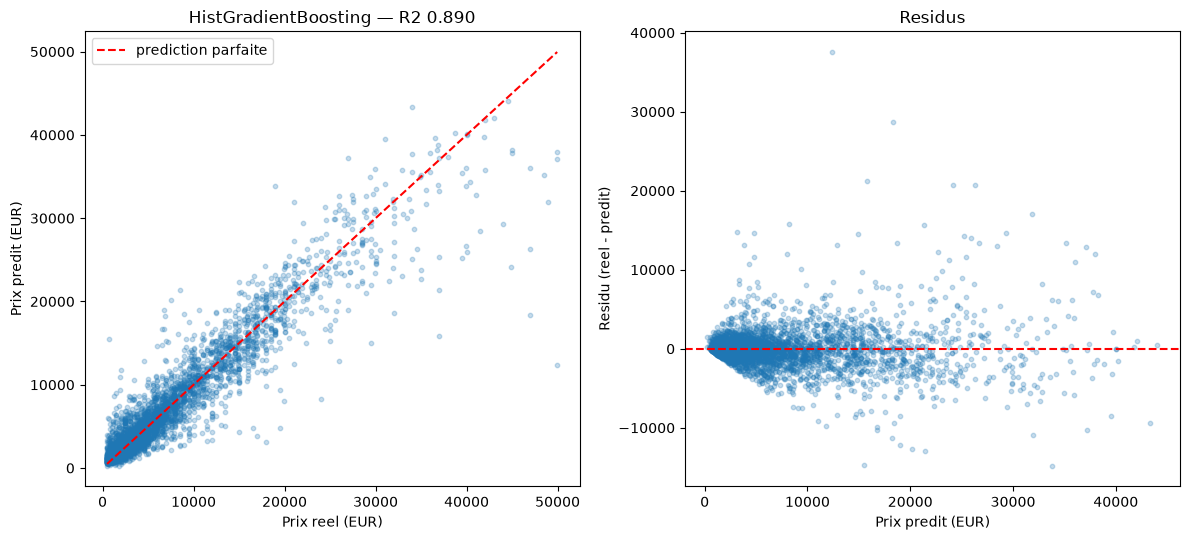

Predictions negatives : 0 / 3977


In [6]:
fig, (g, d) = plt.subplots(1, 2, figsize=(12, 5.5))

g.scatter(y_test, pred_b, alpha=0.25, s=10)
lims = [y_test.min(), y_test.max()]
g.plot(lims, lims, "r--", label="prediction parfaite")
g.set_xlabel("Prix reel (EUR)"); g.set_ylabel("Prix predit (EUR)")
g.set_title(f"{meilleur_nom} — R2 {r2_score(y_test, pred_b):.3f}"); g.legend()

d.scatter(pred_b, y_test - pred_b, alpha=0.25, s=10)
d.axhline(0, color="r", ls="--")
d.set_xlabel("Prix predit (EUR)"); d.set_ylabel("Residu (reel - predit)")
d.set_title("Residus")
plt.tight_layout(); plt.show()

print(f"Predictions negatives : {int((pred_b < 0).sum())} / {len(pred_b)}")

## 5. Le modèle exact (`modele`, 804 modalités)

Trop de modalités pour le catégoriel natif (255 max). Trois encodages comparés :

- **fréquence** : chaque modèle remplacé par son nombre d'occurrences **dans le train** — c'est
  une mesure de popularité, elle ne touche pas à la cible ;
- **prix moyen** (*target encoding*) : très prédictif en théorie, mais fuit la cible sur les
  modèles rares. Le carnet 03 l'a déjà vu dégrader le linéaire ;
- **sans** : référence.

La comparaison est faite en **validation croisée avec recalcul de l'encodage à chaque pli** —
calculer la fréquence une fois sur tout le jeu ferait fuiter le test dans le train.

In [7]:
data_m = df[NUM + CAT + ["modele", "prix_eur"]].copy()
data_m[NUM] = data_m[NUM].astype("float64")
for c in CAT:
    data_m[c] = data_m[c].fillna("(inconnu)").astype("category")

kf = KFold(n_splits=5, shuffle=True, random_state=42)


def cv_encodage(mode):
    maes, r2s = [], []
    for i_tr, i_te in kf.split(data_m):
        tr, te = data_m.iloc[i_tr], data_m.iloc[i_te]
        xtr, xte = tr[NUM + CAT].copy(), te[NUM + CAT].copy()
        if mode == "frequence":
            f = tr["modele"].value_counts()
            xtr["modele_enc"] = tr["modele"].map(f).astype("float64")
            xte["modele_enc"] = te["modele"].map(f).fillna(0).astype("float64")
        elif mode == "prix_moyen":
            pm = tr.groupby("modele")["prix_eur"].mean()
            glob = tr["prix_eur"].mean()
            xtr["modele_enc"] = tr["modele"].map(pm).astype("float64")
            xte["modele_enc"] = te["modele"].map(pm).fillna(glob).astype("float64")
        m = HistGradientBoostingRegressor(categorical_features=CAT, random_state=42)
        m.fit(xtr, tr["prix_eur"])
        p = m.predict(xte)
        maes.append(mean_absolute_error(te["prix_eur"], p))
        r2s.append(r2_score(te["prix_eur"], p))
    return {"encodage": mode, "MAE CV": round(np.mean(maes)), "MAE std": round(np.std(maes)),
            "R2 CV": round(np.mean(r2s), 3)}


print(pd.DataFrame([cv_encodage(m) for m in ("sans", "frequence", "prix_moyen")]).to_string(index=False))
print()
freq_train = X_train.index.to_series().map(df["modele"]).value_counts()
print(f"modeles vus <= 3 fois au train : {int((freq_train <= 3).sum())} / {len(freq_train)}")

  encodage  MAE CV  MAE std  R2 CV
      sans    1519       34  0.887
 frequence    1485       42  0.892
prix_moyen    1465       26  0.893

modeles vus <= 3 fois au train : 341 / 758


## 6. Importance des variables

Importance **par permutation** : on mélange une colonne et on mesure la chute de R². C'est plus
honnête que l'importance interne des arbres, qui surestime les variables à forte cardinalité.

Chute de R2 quand la variable est melangee :
age                  0.4138
puissance_din        0.2077
kilometrage          0.1574
etat                 0.0923
marque               0.0865
puissance_fisc       0.0450
energie_grp          0.0151
places               0.0137
portes               0.0107
boite_auto           0.0065
niveau               0.0027
region               0.0014
critair              0.0002
couleur              0.0001
ct_valide_jusqu_a   -0.0005


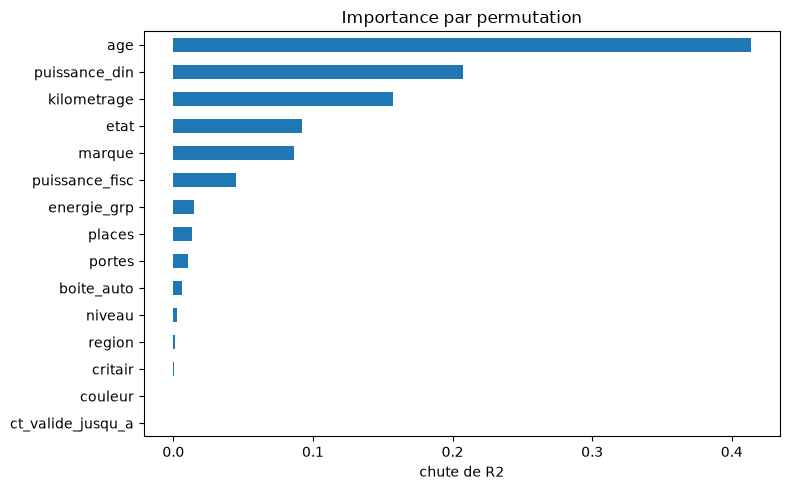

In [8]:
imp = permutation_importance(meilleur, xte_b, y_test, n_repeats=10,
                             random_state=42, scoring="r2", n_jobs=-1)
serie = pd.Series(imp.importances_mean, index=xte_b.columns).sort_values(ascending=False)
print("Chute de R2 quand la variable est melangee :")
print(serie.round(4).to_string())

plt.figure(figsize=(8, 5))
serie.sort_values().plot.barh()
plt.xlabel("chute de R2"); plt.title("Importance par permutation")
plt.tight_layout(); plt.show()

## 7. Bilan

In [9]:
meilleur_ligne = resultats.iloc[0]
gain_mae = 100 * (1 - meilleur_ligne["MAE test"] / MAE_LINEAIRE)

print("=" * 70)
print("MODELES A ARBRES — leboncoin-private")
print("=" * 70)
print(f"Reference lineaire (carnet 03) : MAE {MAE_LINEAIRE:,} EUR | R2 {R2_LINEAIRE} | 425 prix negatifs")
print(f"Meilleur ({meilleur_ligne['modele']}) : MAE {meilleur_ligne['MAE test']:,} EUR | "
      f"R2 {meilleur_ligne['R2 test']} | {meilleur_ligne['pred < 0']} prix negatifs")
print(f"Gain sur la MAE : {gain_mae:.0f} %")
print()
print("Ecart CV / test :", round(meilleur_ligne["R2 test"] - meilleur_ligne["R2 CV moy"], 3),
      "-> si le test depasse nettement la CV, c'est un coup de chance du decoupage,")
print("   pas une meilleure generalisation.")
print()
print("Ce qui reste ouvert :")
print("  - le modele sort un PRIX PONCTUEL. L'exigence produit (ADR 0003) est une")
print("    FOURCHETTE avec incertitude -> carnet suivant, regression quantile + CQR.")
print("  - arbitrage interpretabilite / performance : le lineaire donne des effets en euros,")
print("    l'arbre ne donne qu'une importance relative (attendu BC04).")
print("=" * 70)

MODELES A ARBRES — leboncoin-private
Reference lineaire (carnet 03) : MAE 2,301 EUR | R2 0.789 | 425 prix negatifs
Meilleur (HistGradientBoosting) : MAE 1,475 EUR | R2 0.89 | 0 prix negatifs
Gain sur la MAE : 36 %

Ecart CV / test : 0.011 -> si le test depasse nettement la CV, c'est un coup de chance du decoupage,
   pas une meilleure generalisation.

Ce qui reste ouvert :
  - le modele sort un PRIX PONCTUEL. L'exigence produit (ADR 0003) est une
    FOURCHETTE avec incertitude -> carnet suivant, regression quantile + CQR.
  - arbitrage interpretabilite / performance : le lineaire donne des effets en euros,
    l'arbre ne donne qu'une importance relative (attendu BC04).
